<a href="https://colab.research.google.com/github/mlnjsh/Introduction-to-Deep-Learning/blob/main/notebooks_DeepLearning/01_baseline_keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01. Simple Binary Classification (Baseline MLP) — Keras

We start with the simplest possible neural network for this problem: one hidden layer, sigmoid output, Adam optimizer. Everything else in this series is measured against this baseline.

**Dataset:** `loan_prediction_data.csv` — 614 loan applications, 11 pre-normalised features, binary target `Loan_Status` (1 = approved).

---

## 1. Setup & imports

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
keras.utils.set_random_seed(42)          # reproducible weights + shuffling
print("TensorFlow", tf.__version__, "| Keras", keras.__version__)

TensorFlow 2.20.0 | Keras 3.13.2


## 2. Load the data

In [2]:
import os, numpy as np, pandas as pd
from sklearn.model_selection import train_test_split

# Robust load: works whether the notebook runs from its own folder or the parent
CSV = "loan_prediction_data.csv"
if not os.path.exists(CSV):
    CSV = os.path.join("..", "loan_prediction_data.csv")

df = pd.read_csv(CSV)
print("Shape:", df.shape)
df.head()

Shape: (614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,0.0,0.0,0.000000,1.0,0.0,0.070489,0.000000,0.198860,0.74359,1.0,1.0,1.0
1,LP001003,0.0,1.0,0.333333,1.0,0.0,0.054830,0.036192,0.172214,0.74359,1.0,0.0,0.0
2,LP001005,0.0,1.0,0.000000,1.0,1.0,0.035250,0.000000,0.082489,0.74359,1.0,1.0,1.0
3,LP001006,0.0,1.0,0.000000,0.0,0.0,0.030093,0.056592,0.160637,0.74359,1.0,1.0,1.0
4,LP001008,0.0,0.0,0.000000,1.0,0.0,0.072356,0.000000,0.191027,0.74359,1.0,1.0,1.0


## 3. Prepare features & train/test split

The features are already scaled to `[0,1]`, so we only drop the ID and split. We use a **stratified** split so the approval rate matches in train and test.

In [3]:
# Features are ALREADY normalised to [0,1] in this dataset, so no scaling needed.
# Drop the ID column and separate the target.
X = df.drop(columns=["Loan_ID", "Loan_Status"]).values.astype("float32")
y = df["Loan_Status"].values.astype("float32")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
N_FEATURES = X_train.shape[1]
print("Train:", X_train.shape, " Test:", X_test.shape, " Features:", N_FEATURES)
print("Train positive rate: %.3f  Test positive rate: %.3f" % (y_train.mean(), y_test.mean()))

Train: (491, 11)  Test: (123, 11)  Features: 11
Train positive rate: 0.686  Test positive rate: 0.691


In [4]:
def plot_history(hist, title=""):
    """Plot train (solid) vs test/val (dashed) loss and accuracy over epochs."""
    h = hist.history
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(h["loss"], label="train")
    ax[0].plot(h["val_loss"], "--", label="test")
    ax[0].set_title(title + " — Loss"); ax[0].set_xlabel("epoch"); ax[0].set_ylabel("loss")
    ax[0].legend(); ax[0].grid(alpha=.3)
    ax[1].plot(h["accuracy"], label="train")
    ax[1].plot(h["val_accuracy"], "--", label="test")
    ax[1].set_title(title + " — Accuracy"); ax[1].set_xlabel("epoch"); ax[1].set_ylabel("accuracy")
    ax[1].legend(); ax[1].grid(alpha=.3)
    plt.tight_layout(); plt.show()

## 4. A minimal MLP

- **Input:** 11 features
- **Hidden:** 1 dense layer, 16 units, ReLU
- **Output:** 1 unit, sigmoid → probability of approval

Loss is **binary cross-entropy** — the standard loss for 2-class problems.

In [5]:
def build_baseline():
    model = keras.Sequential([
        keras.Input(shape=(N_FEATURES,)),
        layers.Dense(16, activation="relu"),
        layers.Dense(1,  activation="sigmoid"),
    ])
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model

model = build_baseline()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209 (836.00 B)

 Trainable params: 209 (836.00 B)

 Non-trainable params: 0 (0.00 B)

## 5. Train

We pass the test set as `validation_data` so Keras records test loss/accuracy every epoch — that is what lets us draw the train-vs-test curves.

In [6]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100, batch_size=32, verbose=0,
)
print("Done. Final epoch:")
print("  train acc = %.3f | test acc = %.3f" %
      (history.history["accuracy"][-1], history.history["val_accuracy"][-1]))

Done. Final epoch:
  train acc = 0.800 | test acc = 0.862


## 6. Train vs test curves

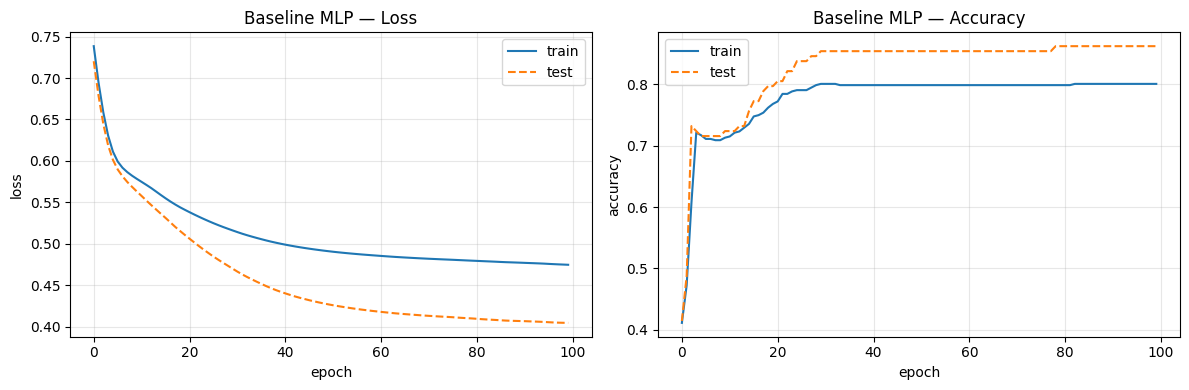

In [7]:
plot_history(history, "Baseline MLP")

## 7. Evaluate

In [8]:
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print("Test loss: %.4f | Test accuracy: %.4f" % (loss, acc))

Test loss: 0.4048 | Test accuracy: 0.8618


## 8. Confusion matrix & ROC curve

Accuracy alone hides *how* the model is wrong. The **confusion matrix** shows the four outcomes (true/false × positive/negative); the **ROC curve** and its **AUC** summarise performance across every decision threshold, not just 0.5.

              precision    recall  f1-score   support

Rejected (0)       0.96      0.58      0.72        38
Approved (1)       0.84      0.99      0.91        85

    accuracy                           0.86       123
   macro avg       0.90      0.78      0.81       123
weighted avg       0.88      0.86      0.85       123



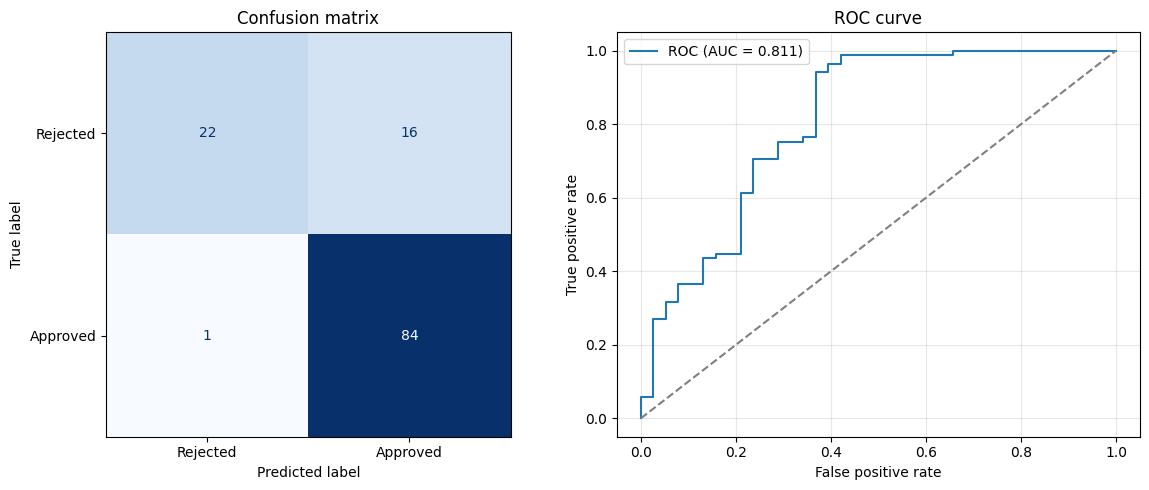

AUC = 0.811


In [9]:
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, auc, classification_report)

y_prob = model.predict(X_test, verbose=0).ravel()
y_pred = (y_prob > 0.5).astype(int)

print(classification_report(y_test, y_pred, target_names=["Rejected (0)", "Approved (1)"]))

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["Rejected", "Approved"]).plot(
    ax=ax[0], colorbar=False, cmap="Blues")
ax[0].set_title("Confusion matrix")

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
ax[1].plot(fpr, tpr, label="ROC (AUC = %.3f)" % roc_auc)
ax[1].plot([0, 1], [0, 1], "--", color="grey")
ax[1].set_xlabel("False positive rate"); ax[1].set_ylabel("True positive rate")
ax[1].set_title("ROC curve"); ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()
print("AUC = %.3f" % roc_auc)

In [17]:
def build_baseline():
    model = keras.Sequential([
        tf.keras.Input(shape=(11,)),

    # First hidden layer: 10 neurons
    Dense(10, activation="relu"),

    # Second hidden layer: 8 neurons
    Dense(8, activation="relu"),

    # Third hidden layer: 5 neurons
    Dense(5, activation="relu"),

    # Fourth hidden layer: 3 neurons
    Dense(3, activation="relu"),

    # Output layer: 1 neuron
    Dense(1, activation="sigmoid")
    ])
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model

model = build_baseline()
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_27 (Dense)                │ (None, 10)             │           120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 8)              │            88 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 5)              │            45 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 3)              │            18 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 275 (1.07 KB)

 Trainable params: 275 (1.07 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100, batch_size=32, verbose=0,
)
print("Done. Final epoch:")
print("  train acc = %.3f | test acc = %.3f" %
      (history.history["accuracy"][-1], history.history["val_accuracy"][-1]))

Done. Final epoch:
  train acc = 0.802 | test acc = 0.846


## Takeaways
- A tiny 1-hidden-layer network already reaches a strong accuracy on this problem — the signal (especially `Credit_History`) is easy to learn.
- The confusion matrix reveals the error *type*: on imbalanced approval data the model often misses the minority class even at high accuracy — worth checking before trusting accuracy alone.
- **AUC** is threshold-independent: it answers "how well does the model *rank* approvals above rejections?" — a more robust score than accuracy at a fixed 0.5 cutoff.
- Watch the gap between the solid (train) and dashed (test) curves: if train accuracy keeps climbing while test flattens, the model is starting to **overfit**. The later notebooks (dropout, early stopping, batch-norm) are all tools to manage that gap.
- **Next:** `02_optimizers_keras` — does the *choice of optimizer* change how fast and how well we converge?